# Vue d'ensemble du dataset

In [57]:
# Étape 5 : Interprétation et Visualisation

# imports
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns

print("imports done")

# chargement du fichier csv
df = pd.read_csv("our_dataset.csv")

imports done


In [58]:
print(df.shape)
print()
print(df.head())
print()
print()
print(df["Éditeur"].unique())

(1351, 14)

               ID_ANSSI                                     Titre_ANSSI  Type  \
0  CERTFR-2026-AVI-0699        Vulnérabilité dans Cisco Catalyst SD-WAN  Avis   
1  CERTFR-2026-AVI-0715  Multiples vulnérabilités dans les produits SAP  Avis   
2  CERTFR-2026-AVI-0715  Multiples vulnérabilités dans les produits SAP  Avis   
3  CERTFR-2026-AVI-0715  Multiples vulnérabilités dans les produits SAP  Avis   
4  CERTFR-2026-AVI-0715  Multiples vulnérabilités dans les produits SAP  Avis   

          Date                                         Lien_ANSSI  \
0  05 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
1  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
2  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
3  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
4  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   

              CVE  CVSS Base_Severity      CWE  \
0  CVE-2026-20245   7.8          HIG

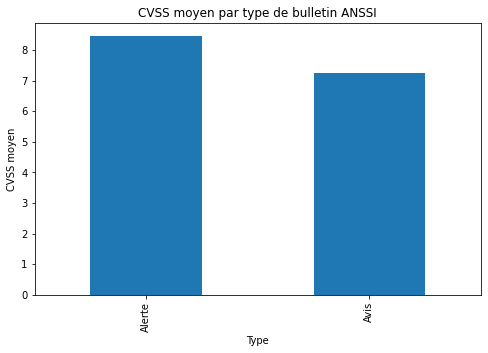

In [59]:
df.groupby("Type")["CVSS"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("CVSS moyen par type de bulletin ANSSI")
plt.ylabel("CVSS moyen")

plt.show()

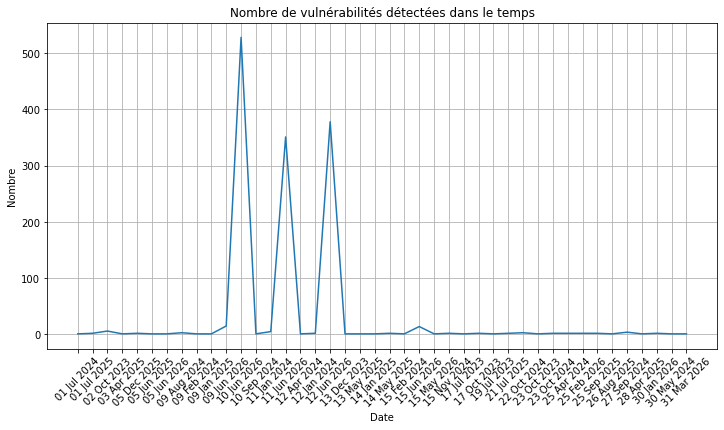

In [62]:
evolution = (
    df.groupby("Date")
      .size()
      .sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    evolution.index,
    evolution.values
)

plt.title("Nombre de vulnérabilités détectées dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre")
plt.xticks(rotation=45)
plt.grid()

plt.show()

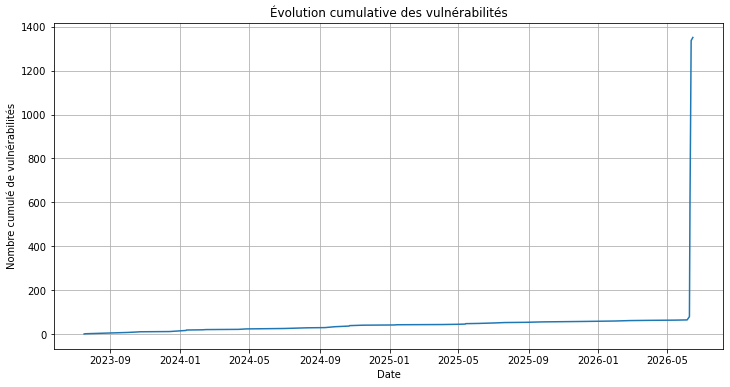

In [63]:
df["Date"] = pd.to_datetime(df["Date"])

evolution = (
    df.groupby("Date")
      .size()
      .sort_index()
      .cumsum()
)

plt.figure(figsize=(12,6))

plt.plot(
    evolution.index,
    evolution.values
)

plt.title("Évolution cumulative des vulnérabilités")
plt.xlabel("Date")
plt.ylabel("Nombre cumulé de vulnérabilités")

plt.grid()

plt.show()

# Analyse de la gravité

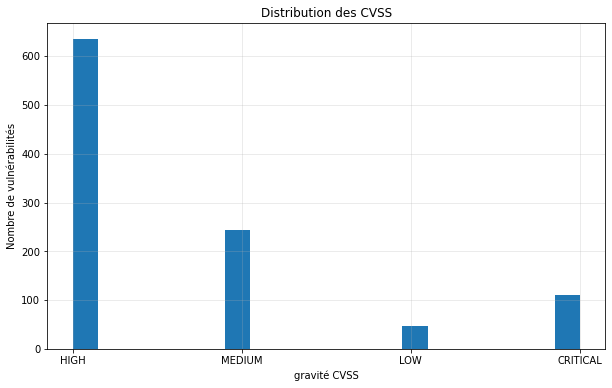

In [64]:
# Histogramme des scores CVSS
# Pour observer la distribution des vulnérabilités selon leur gravité/Base_Severity.


plt.figure(figsize=(10,6))

plt.hist(df["Base_Severity"].dropna(), bins=20)

plt.xlabel("gravité CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.title("Distribution des CVSS")

plt.grid(alpha=0.3)

plt.show()

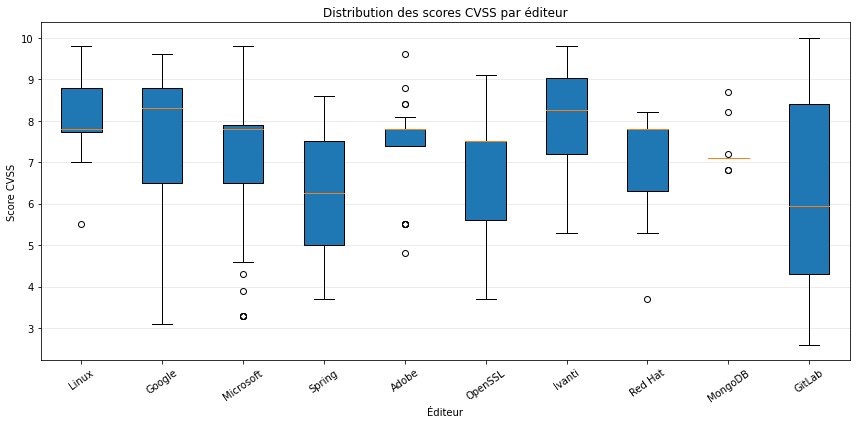

In [68]:
# Boxplot CVSS par éditeur
# Montre la dispersion des scores CVSS pour les éditeurs ayant le plus de vulnérabilités.


# Top 10 éditeurs les plus représentés
top_editors = (df["Éditeur"].value_counts().head(10).index)

df_top = df[df["Éditeur"].isin(top_editors)]

data = [
    df_top[df_top["Éditeur"] == vendor]["CVSS"].dropna()
    for vendor in top_editors
]

plt.figure(figsize=(12,6))

plt.boxplot(data, labels=top_editors, patch_artist=True)

plt.ylabel("Score CVSS")
plt.xlabel("Éditeur")
plt.title("Distribution des scores CVSS par éditeur")

plt.xticks(rotation=35)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

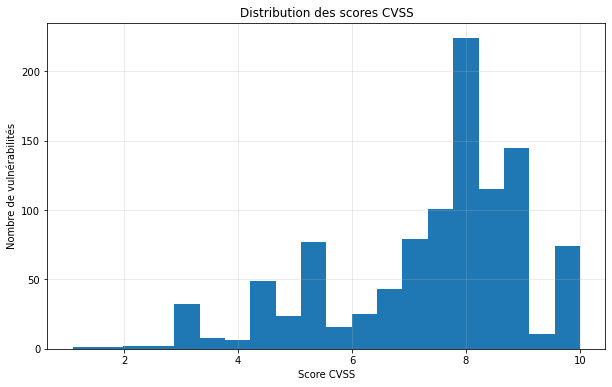

In [69]:
# Histogramme des scores CVSS
# Pour observer la distribution des vulnérabilités selon leur score.


plt.figure(figsize=(10,6))

plt.hist(df["CVSS"].dropna(), bins=20)

plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.title("Distribution des scores CVSS")

plt.grid(alpha=0.3)

plt.show()

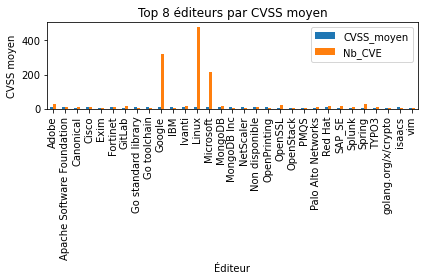

In [76]:
vendor_risk = (
    df.groupby("Éditeur")
      .agg(
          CVSS_moyen=("CVSS", "mean"),
          Nb_CVE=("CVE", "count")
      )
)

vendor_risk = vendor_risk[
    vendor_risk["Nb_CVE"] >= 3
]
vendor_risk.plot(kind="bar")

plt.title("Top 8 éditeurs par CVSS moyen")
plt.xlabel("Éditeur")
plt.ylabel("CVSS moyen")

plt.tight_layout()
plt.show()

# Analyse des risques

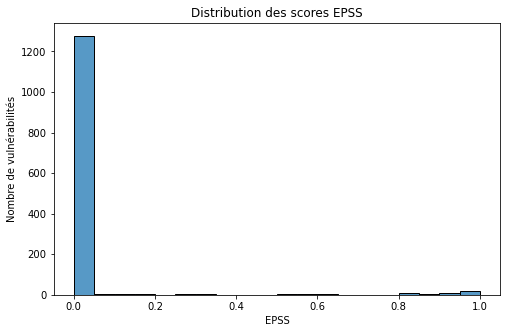

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["EPSS"],
    bins=20
)

plt.title("Distribution des scores EPSS")
plt.xlabel("EPSS")
plt.ylabel("Nombre de vulnérabilités")

plt.show()

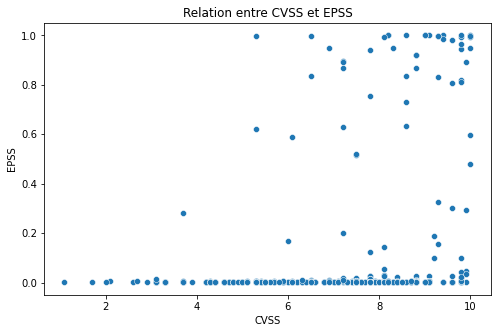

In [78]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="CVSS",
    y="EPSS"
)

plt.title("Relation entre CVSS et EPSS")

plt.show()

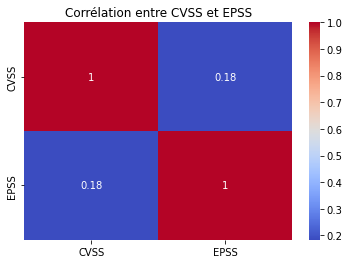

In [79]:
import seaborn as sns

corr = df[["CVSS", "EPSS"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Corrélation entre CVSS et EPSS")

plt.show()

# Analyse des vulnérabilités (CWE)

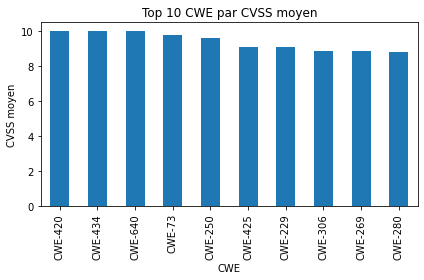

In [80]:
import matplotlib.pyplot as plt

top = (
    df.groupby("CWE")["CVSS"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

top.plot(kind="bar")

plt.title("Top 10 CWE par CVSS moyen")
plt.xlabel("CWE")
plt.ylabel("CVSS moyen")

plt.tight_layout()
plt.show()


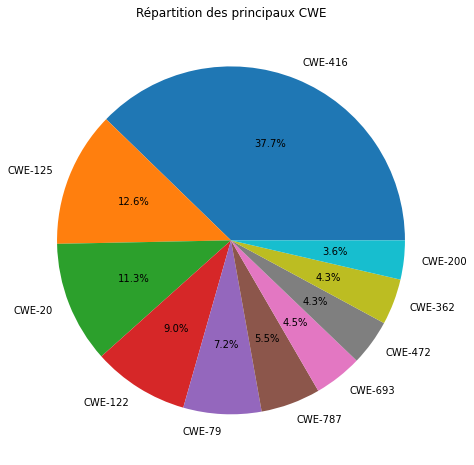

In [81]:
top_cwe = df["CWE"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_cwe,
    labels=top_cwe.index,
    autopct="%1.1f%%"
)

plt.title("Répartition des principaux CWE")

plt.show()

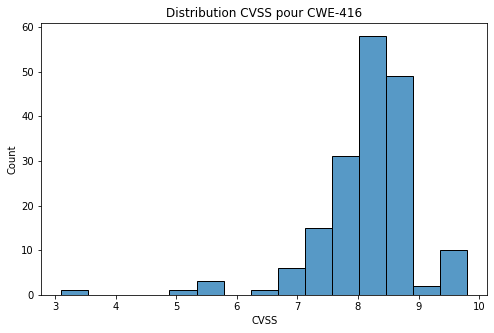

In [82]:
top_cwe = df["CWE"].value_counts().idxmax()

subset = df[df["CWE"] == top_cwe]

plt.figure(figsize=(8,5))

sns.histplot(
    subset["CVSS"].dropna(),
    bins=15
)

plt.title(f"Distribution CVSS pour {top_cwe}")

plt.show()

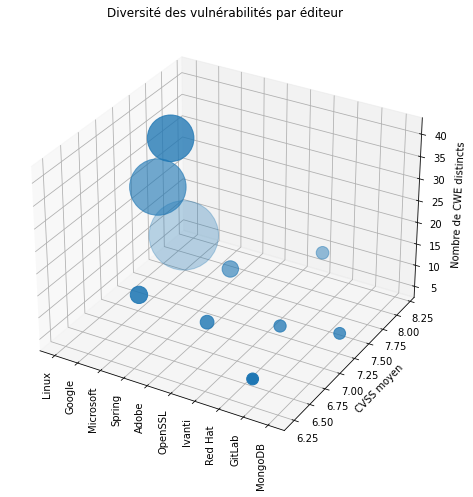

In [83]:
# Test de Graphique 3D : Éditeur x CVSS moyen x Variété CWE


# X = éditeur
# Y = CVSS moyen
# Z = nombre de CWE différents

# Pour identifier :
# les éditeurs avec beaucoup de vulnérabilités différentes ;
# ceux qui ont toujours les mêmes erreurs ;
# ceux qui combinent diversité de CWE et forte criticité.


stats = (
    df.groupby("Éditeur")
      .agg(
          cvss_mean=("CVSS","mean"),
          nb_cwe=("CWE","nunique"),
          nb_cve=("CVE","count")
      )
      .sort_values("nb_cve", ascending=False)
      .head(10)
)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    range(len(stats)),
    stats["cvss_mean"],
    stats["nb_cwe"],
    s=stats["nb_cve"]*10
)

ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats.index,
    rotation=90
)

ax.set_ylabel("CVSS moyen")
ax.set_zlabel("Nombre de CWE distincts")

plt.title("Diversité des vulnérabilités par éditeur")

plt.show()

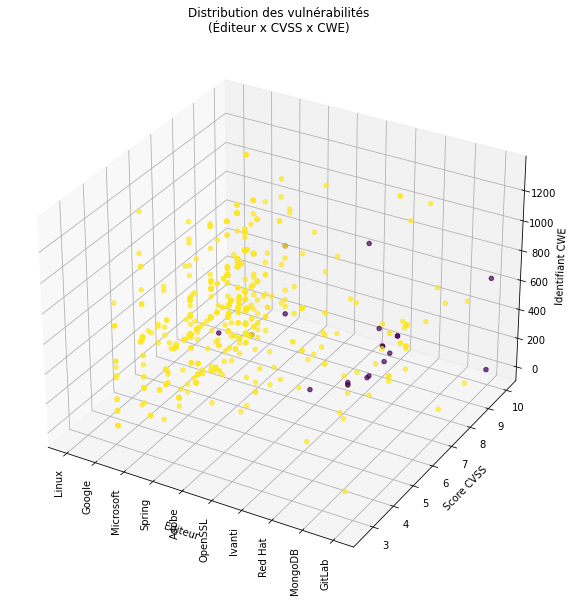

In [84]:
# Nuage de points 3D : Éditeur × CVSS × CWE

#Chaque point = une vulnérabilité.
#Axe X = éditeur
#Axe Y = score CVSS
#Axe Z = CWE
#Couleur = type de bulletin (Avis/Alerte)

#Pour voir :
#les éditeurs qui accumulent les CVE critiques ;
#les CWE dominants ;
#les regroupements intéressants.


# Encodage des catégories
top_editors = (df["Éditeur"].value_counts().head(10).index)

df_plot = df[df["Éditeur"].isin(top_editors)].copy()

df_plot["editor_id"] = pd.Categorical(
    df_plot["Éditeur"],
    categories=top_editors
).codes

df_plot["cwe_id"] = (
    df_plot["CWE"]
    .astype(str)
    .str.extract(r'(\d+)')
    .fillna(0)
    .astype(int)
)

fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_plot["editor_id"],
    df_plot["CVSS"],
    df_plot["cwe_id"],
    c=pd.Categorical(df_plot["Type"]).codes,
    alpha=0.7
)

ax.set_xlabel("Éditeur")
ax.set_ylabel("Score CVSS")
ax.set_zlabel("Identifiant CWE")

ax.set_xticks(range(len(top_editors)))
ax.set_xticklabels(top_editors, rotation=90)

plt.title(
    "Distribution des vulnérabilités\n"
    "(Éditeur x CVSS x CWE)"
)

plt.show()

# Analyse des éditeurs et produits

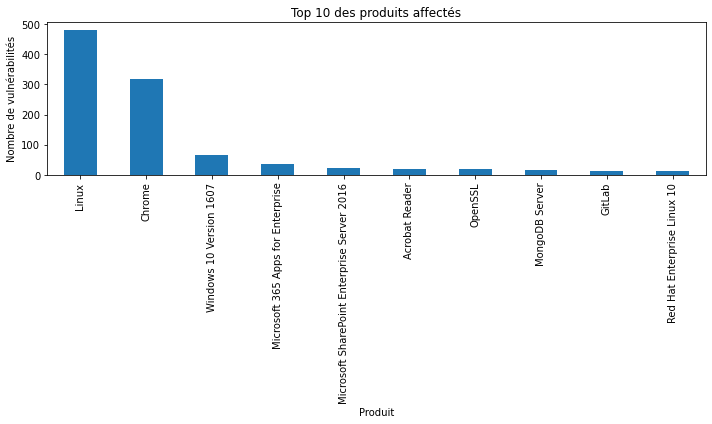

In [85]:
top_product = df["Produit"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_product.plot(kind="bar")

plt.title("Top 10 des produits affectés")
plt.xlabel("Produit")
plt.ylabel("Nombre de vulnérabilités")

plt.tight_layout()
plt.show()

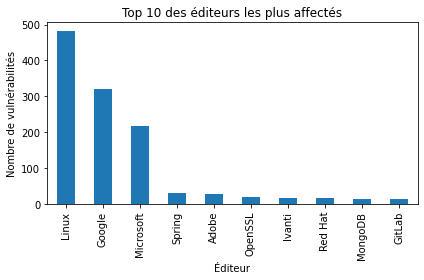

In [86]:
top_vendor = (
    df["Éditeur"]
      .value_counts()
      .head(10)
)

top_vendor.plot(kind="bar")

plt.title("Top 10 des éditeurs les plus affectés")
plt.xlabel("Éditeur")
plt.ylabel("Nombre de vulnérabilités")

plt.tight_layout()
plt.show()

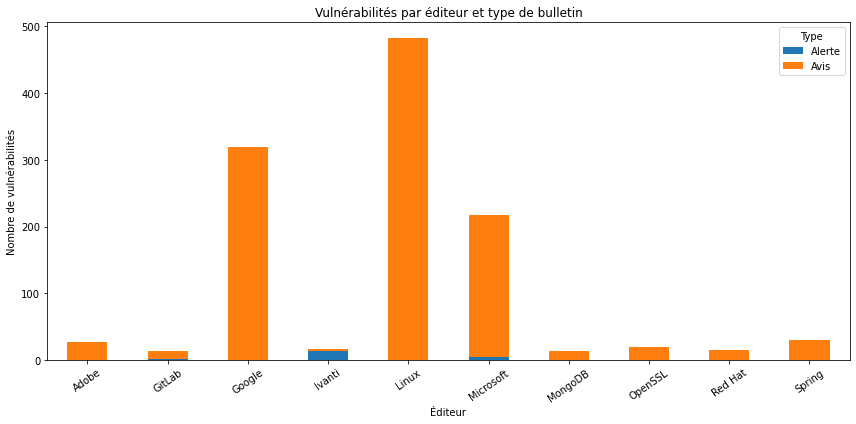

In [87]:
# Nombre de vulnérabilités par éditeur et type de bulletin
# Pour voir quels éditeurs génèrent le plus d'alertes critiques.


top_editors = (df["Éditeur"].value_counts().head(10).index)

df_top = df[df["Éditeur"].isin(top_editors)]

pivot = pd.crosstab(df_top["Éditeur"], df_top["Type"])

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Vulnérabilités par éditeur et type de bulletin")
plt.xlabel("Éditeur")
plt.ylabel("Nombre de vulnérabilités")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

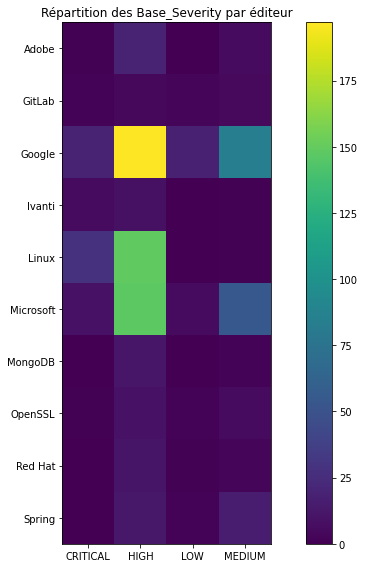

In [88]:
# Heatmap Éditeur x Base_Severity


top_editors = (df["Éditeur"].value_counts().head(10).index)

df_top = df[df["Éditeur"].isin(top_editors)]

heatmap = pd.crosstab(df_top["Éditeur"], df_top["Base_Severity"])

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(heatmap)

ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)

ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)

plt.colorbar(im)

plt.title("Répartition des Base_Severity par éditeur")

plt.tight_layout()
plt.show()

# Modèles Machine learning

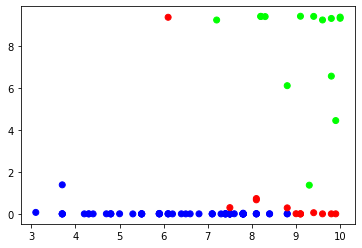

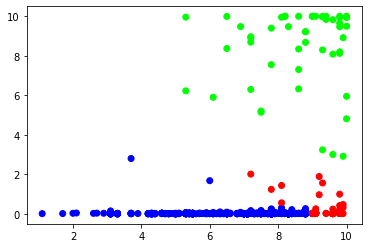

In [93]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans


def prepare_data(csv):
    df = pd.read_csv(csv)
    new_df = df.dropna(subset=["CVSS"])
    new_df = new_df.dropna(subset=["EPSS"])
    new_df.reset_index(drop=True, inplace=True)
    new_df["EPSS"] = new_df["EPSS"]*10
    return new_df


def get_training_data():
    return pd.read_csv("train_data.csv")


def do_knn_classification(display):
    model = KNeighborsClassifier(n_neighbors=3)
    # handpicked data (not very representative)
    training_data = get_training_data()
    x_training_data = training_data.drop(columns=["CLASS"])
    y_training_data = training_data["CLASS"]
    model.fit(x_training_data, y_training_data)

    test_data = prepare_data("our_dataset.csv")
    # 2: always sends email, 1: sends email to subscriber with warning level 0 and 1, 0: sends email only to subscriber with warning level 0
    y_pred = model.predict(test_data[["CVSS", "EPSS"]])

    if display is True:
        plt.scatter(x_training_data["CVSS"], x_training_data["EPSS"], c=y_training_data, cmap="brg")
        plt.show()
        plt.scatter(test_data["CVSS"], test_data["EPSS"], c=y_pred, cmap="brg")
        plt.show()

    return test_data, y_pred


# since KMeans is unsupervised I did not choose the values of the labels
def do_kmeans(display):
    model = KMeans(3, random_state=42)
    training_data = get_training_data()
    x_training_data = training_data.drop(columns=["CLASS"])
    y_training_data = training_data["CLASS"]
    model.fit(x_training_data)

    test_data = prepare_data("our_dataset.csv")
    # label 0 is priority 2, label 1 is priority 1, label 2 is priority 0
    y_pred = model.predict(test_data[["CVSS", "EPSS"]])

    if display is True:
        plt.scatter(x_training_data["CVSS"], x_training_data["EPSS"], c=y_training_data, cmap="brg")
        plt.show()
        plt.scatter(test_data["CVSS"], test_data["EPSS"], c=y_pred, cmap="brg")
        plt.show()

    return test_data, y_pred


if __name__ == '__main__':
    knn_prediction = do_knn_classification(True)


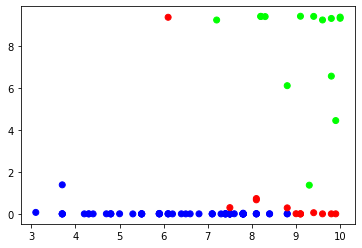

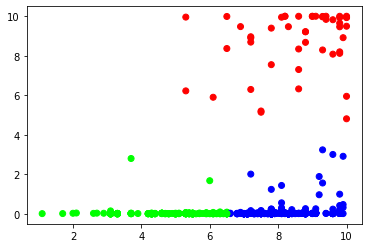

In [94]:
kmeans_prediction = do_kmeans(True)